<a href="https://colab.research.google.com/github/willismax/MediaSystem-Python-Course/blob/main/13.Image-Processing/%E5%8D%B7%E7%A9%8D%E3%80%81%E6%BF%BE%E6%B3%A2%E8%88%87%E9%A0%BB%E5%9F%9F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05｜卷積、濾波與頻域：從單一像素到鄰域處理

本章核心重點：
1. **Neighborhood Processing**：當像素的新值取決於周圍像素時的運算方式。
2. **Kernel (核)**：決定濾鏡效果的小型矩陣權重設計。
3. **Convolution vs Correlation**：理解數學定義與程式實作的差異。
4. **OpenCV 實務**：高效率處理與 BGR 通道陷阱。

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def filter_gray(img, kernel):
    """
    教學用的鄰域濾波 (手寫實作)
    直接做 region * kernel，形式上屬於 Correlation。
    """
    h, w = img.shape
    kh, kw = kernel.shape

    # 計算需要的 Padding 大小
    pad_y, pad_x = kh // 2, kw // 2

    # 使用邊界複製模式進行 Padding
    padded = np.pad(
        img.astype(np.float64),
        ((pad_y, pad_y), (pad_x, pad_x)),
        mode="edge"
    )

    out = np.zeros((h, w), dtype=np.float64)

    # 雙層迴圈掃描圖片 (教學用，效能較低)
    for y in range(h):
        for x in range(w):
            region = padded[y:y + kh, x:x + kw]
            out[y, x] = np.sum(region * kernel)

    return out

## 5.4 - 5.5 經典 Kernel 定義與手寫測試
我們將定義三種經典 Kernel 並觀察其權重總和對亮度的影響。

In [2]:
# 1. 平均模糊 (Blur): 總和為 1
blur_k = np.ones((3, 3), dtype=np.float64) / 9

# 2. 銳化 (Sharpen): 總和為 1
sharpen_k = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

# 3. 拉普拉斯邊緣偵測 (Laplacian): 總和為 0
laplacian_k = np.array([
    [0,  1, 0],
    [1, -4, 1],
    [0,  1, 0]
])

print(f"Blur Sum: {blur_k.sum()}")
print(f"Sharpen Sum: {sharpen_k.sum()}")
print(f"Laplacian Sum: {laplacian_k.sum()}")

Blur Sum: 1.0
Sharpen Sum: 1
Laplacian Sum: 0


## 5.9 處理負值與顯示 Edge
拉普拉斯算子會產生負值。如果直接 `clip(0, 255)`，會損失一半的邊緣資訊。建議取絕對值後再進行正規化。

In [3]:
def show_edge(edge_map):
    # 取絕對值並轉換為 uint8 以利顯示
    abs_edge = np.abs(edge_map)
    display_edge = np.clip(abs_edge, 0, 255).astype(np.uint8)
    plt.imshow(display_edge, cmap='gray')
    plt.title("Edge Map (Absolute Value)")
    plt.show()

## 5.12 - 5.13 OpenCV 實務與 BGR 陷阱
使用 OpenCV 讀取圖片時，務必檢查讀取是否成功，並注意 `BGR -> RGB` 的轉換。

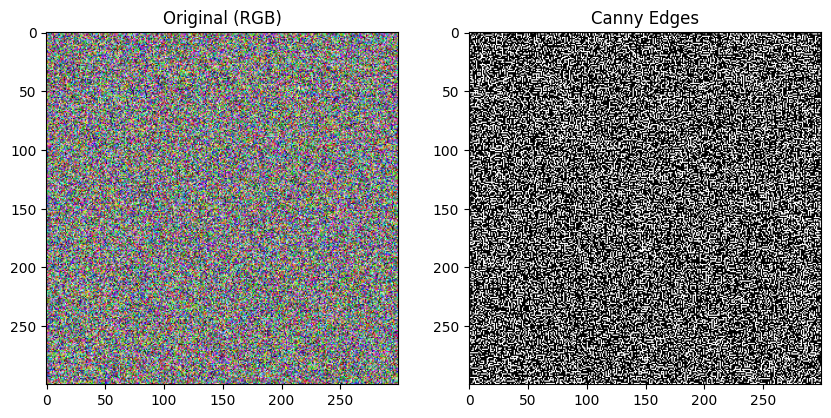

In [4]:
# 讀取圖片示範 (請確保路徑正確)
try:
    # 模擬讀取一張全灰圖作為範例，實務請用 cv2.imread("photo.jpg")
    img_bgr = (np.random.rand(300, 300, 3) * 255).astype(np.uint8)

    if img_bgr is None:
        raise ValueError("圖片讀取失敗，請檢查路徑")

    # 正確顯示方式
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 使用 OpenCV 的最佳化函式
    blur_cv = cv2.GaussianBlur(img_rgb, (15, 15), 0)
    edges_cv = cv2.Canny(cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY), 80, 160)

    plt.figure(figsize=(10, 5))
    plt.subplot(121); plt.imshow(img_rgb); plt.title("Original (RGB)")
    plt.subplot(122); plt.imshow(edges_cv, cmap='gray'); plt.title("Canny Edges")
    plt.show()

except Exception as e:
    print(f"錯誤: {e}")

## 5.23 延伸實作：馬賽克效果
利用降低空間取樣 (Resize) 與最近鄰插值來達成馬賽克。

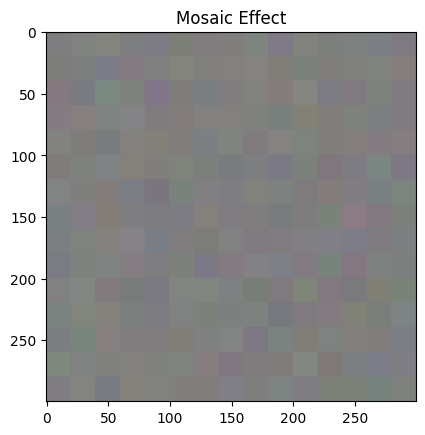

In [5]:
def mosaic(region, block=12):
    h, w = region.shape[:2]
    # 縮小
    small = cv2.resize(
        region,
        (max(1, w // block), max(1, h // block)),
        interpolation=cv2.INTER_AREA
    )
    # 放大 (使用 NEAREST 保留方格感)
    return cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)

# 測試馬賽克
test_mosaic = mosaic(img_rgb, block=20)
plt.imshow(test_mosaic)
plt.title("Mosaic Effect")
plt.show()

### 基礎練習建議
1. 使用 `filter_gray` 比較三種 Kernel 並計算其輸出結果。
2. 調整 `cv2.Canny` 的門檻值 (Threshold)，觀察邊緣數量的變化。
3. 故意不轉換 BGR 就使用 `plt.imshow`，紀錄顏色變異狀況。

# 延伸挑戰

## 挑戰一｜素描濾鏡實作
請嘗試利用以下流程建立素描濾鏡：
1. RGB -> Gray
2. Gray -> Invert (反轉)
3. Gaussian Blur (對反轉圖進行模糊)
4. Color Dodge 混合: `gray * 255 / (255 - blur)`

## 挑戰二｜手寫 vs OpenCV 效能分析
使用 `time` 模組比較 `filter_gray()` 與 `cv2.filter2D()` 在處理 1080p 圖片時的耗時差距。

# 檢核題 (Self-Check)

1. **Pixel-wise** 與 **Neighborhood Operation** 最大差異是什麼？
2. 為什麼 **Average Blur** 的權重總和通常是 1？
3. 為什麼 **Edge Detection** (如 Laplacian) 的權重總和常接近 0？
4. 使用 **Laplacian** 時，為什麼不應立刻將結果 `clip(0, 255)`？
5. **OpenCV** 的 BGR 陷阱會造成什麼視覺現象？
6. 簡述 **Spatial Domain** (空間域) 與 **Frequency Domain** (頻域) 的觀察視角差異。

---
**下一章預告：06｜擴散模型如何學會去噪**
我們將從傳統影像處理跨入 Generative AI，看電腦如何從雜訊中生成影像。

# 延伸挑戰

## 挑戰一｜素描濾鏡實作
請嘗試利用以下流程建立素描濾鏡：
1. RGB -> Gray
2. Gray -> Invert (反轉)
3. Gaussian Blur (對反轉圖進行模糊)
4. Color Dodge 混合: `gray * 255 / (255 - blur)`

## 挑戰二｜手寫 vs OpenCV 效能分析
使用 `time` 模組比較 `filter_gray()` 與 `cv2.filter2D()` 在處理 1080p 圖片時的耗時差距。

# 檢核題 (Self-Check)

1. **Pixel-wise** 與 **Neighborhood Operation** 最大差異是什麼？
2. 為什麼 **Average Blur** 的權重總和通常是 1？
3. 為什麼 **Edge Detection** (如 Laplacian) 的權重總和常接近 0？
4. 使用 **Laplacian** 時，為什麼不應立刻將結果 `clip(0, 255)`？
5. **OpenCV** 的 BGR 陷阱會造成什麼視覺現象？
6. 簡述 **Spatial Domain** (空間域) 與 **Frequency Domain** (頻域) 的觀察視角差異。

---
**下一章預告：06｜擴散模型如何學會去噪**
我們將從傳統影像處理跨入 Generative AI，看電腦如何從雜訊中生成影像。

# 延伸挑戰

## 挑戰一｜素描濾鏡實作
請嘗試利用以下流程建立素描濾鏡：
1. RGB -> Gray
2. Gray -> Invert (反轉)
3. Gaussian Blur (對反轉圖進行模糊)
4. Color Dodge 混合: `gray * 255 / (255 - blur)`

## 挑戰二｜手寫 vs OpenCV 效能分析
使用 `time` 模組比較 `filter_gray()` 與 `cv2.filter2D()` 在處理 1080p 圖片時的耗時差距。

# 檢核題 (Self-Check)

1. **Pixel-wise** 與 **Neighborhood Operation** 最大差異是什麼？
2. 為什麼 **Average Blur** 的權重總和通常是 1？
3. 為什麼 **Edge Detection** (如 Laplacian) 的權重總和常接近 0？
4. 使用 **Laplacian** 時，為什麼不應立刻將結果 `clip(0, 255)`？
5. **OpenCV** 的 BGR 陷阱會造成什麼視覺現象？
6. 簡述 **Spatial Domain** (空間域) 與 **Frequency Domain** (頻域) 的觀察視角差異。

---
**下一章預告：06｜擴散模型如何學會去噪**
我們將從傳統影像處理跨入 Generative AI，看電腦如何從雜訊中生成影像。